In [1]:
import os
import re
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import spacy

os.environ["OMP_NUM_THREADS"] = "4"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

DATA_DIR = "/kaggle/input/jigsaw-toxic-comment-classification-challenge"
if not os.path.exists(DATA_DIR):
    DATA_DIR = "/kaggle/data/jigsaw-toxic-comment-classification-challenge"

TRAIN_PATH = os.path.join(DATA_DIR, "train.csv")
TEST_PATH = os.path.join(DATA_DIR, "test.csv")
SAMPLE_SUB_PATH = os.path.join(DATA_DIR, "sample_submission.csv")



In [2]:
# Bugfix: spacy.load('en') is invalid in modern spaCy; use en_core_web_sm if present, else blank English.
try:
    my_tok = spacy.load(
        "en_core_web_sm", disable=["parser", "ner", "tagger", "lemmatizer"]
    )
except Exception:
    my_tok = spacy.blank("en")

my_stopwords = spacy.lang.en.stop_words.STOP_WORDS
my_stopwords = set(my_stopwords)
my_stopwords.update(["wikipedia", "article", "articles", "im", "page"])

_token_re_non_alpha = re.compile(r"[^a-zA-Z\s]")
_token_re_newline = re.compile(r"[\n\r\t]+")


def spacy_tok(x: str):
    if not isinstance(x, str):
        x = ""
    x = x.lower()
    x = _token_re_newline.sub(" ", x)
    x = _token_re_non_alpha.sub(" ", x)
    toks = [t.text for t in my_tok.tokenizer(x)]
    toks = [t for t in toks if t and (t not in my_stopwords)]
    return toks




In [3]:
# Read data
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
sample_sub = pd.read_csv(SAMPLE_SUB_PATH)

TARGET_COLS = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
assert all(c in train_df.columns for c in TARGET_COLS), "Train missing target columns"
assert "comment_text" in train_df.columns and "comment_text" in test_df.columns
assert "id" in train_df.columns and "id" in test_df.columns

# Deterministic split similar to torchtext's default behavior but explicit
idx = np.arange(len(train_df))
rng = np.random.RandomState(SEED)
rng.shuffle(idx)
split = int(0.7 * len(idx))
train_idx, val_idx = idx[:split], idx[split:]

train_split_df = train_df.iloc[train_idx].reset_index(drop=True)
val_split_df = train_df.iloc[val_idx].reset_index(drop=True)



In [4]:
# Minimal torchtext replacement: vocab + numericalization + padding + lengths
PAD = "<pad>"
UNK = "<unk>"
EOS = "EOS"


def build_vocab(texts, min_freq=2, max_size=200000):
    from collections import Counter

    counter = Counter()
    for x in texts:
        toks = spacy_tok(x)
        toks.append(EOS)
        counter.update(toks)
    # keep most common
    it = [(w, c) for w, c in counter.most_common() if c >= min_freq]
    if max_size is not None:
        it = it[: max(0, max_size - 2)]
    stoi = {PAD: 0, UNK: 1}
    for w, _ in it:
        if w not in stoi:
            stoi[w] = len(stoi)
    return stoi


stoi = build_vocab(train_split_df["comment_text"].tolist(), min_freq=2, max_size=200000)
itos = [None] * len(stoi)
for k, v in stoi.items():
    itos[v] = k


def numericalize(text):
    toks = spacy_tok(text)
    toks.append(EOS)
    return [stoi.get(t, stoi[UNK]) for t in toks]




In [5]:
# Use pretrained embeddings if available locally; otherwise fall back to random init (still runs end-to-end).
# This preserves the "frozen pretrained embeddings" core logic by freezing either way.
def load_fasttext_simple_300d(itos, emb_dim=300):
    # Try common Kaggle input locations; if not found return None.
    candidate_paths = [
        "/kaggle/input/fasttext-simple-english/fasttext.simple.300d.vec",
        "/kaggle/input/fasttext-wiki-news-subwords-300/fasttext-wiki-news-subwords-300.vec",
        "/kaggle/input/wiki-news-300d-1m/wiki-news-300d-1M.vec",
    ]
    vec_path = next((p for p in candidate_paths if os.path.exists(p)), None)
    if vec_path is None:
        return None

    vectors = np.random.normal(scale=0.02, size=(len(itos), emb_dim)).astype(np.float32)
    vectors[0] = 0.0  # PAD
    found = 0

    # Read .vec format: first line can be "n d" or a word vector.
    with open(vec_path, "r", encoding="utf-8", errors="ignore") as f:
        first = f.readline()
        parts = first.rstrip().split()
        if len(parts) != emb_dim + 1:
            # first line is header -> proceed
            pass
        else:
            word = parts[0]
            if word in stoi:
                vectors[stoi[word]] = np.asarray(parts[1:], dtype=np.float32)
                found += 1
        for line in f:
            parts = line.rstrip().split()
            if len(parts) != emb_dim + 1:
                continue
            word = parts[0]
            idx = stoi.get(word, None)
            if idx is not None:
                vectors[idx] = np.asarray(parts[1:], dtype=np.float32)
                found += 1
    return torch.tensor(vectors), found, vec_path


pretrained = load_fasttext_simple_300d(itos, emb_dim=300)
if pretrained is None:
    vectors = torch.randn(len(itos), 300) * 0.02
    vectors[0].zero_()
    loaded_info = "No pretrained vectors found; using random vectors."
else:
    vectors, found, vec_path = pretrained
    loaded_info = f"Loaded vectors from {vec_path}; matched {found}/{len(itos)} tokens."
print(loaded_info)




No pretrained vectors found; using random vectors.


In [6]:
class ToxicDataset(Dataset):
    def __init__(self, df, is_test=False):
        self.df = df
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        x = numericalize(row["comment_text"])
        if self.is_test:
            return row["id"], torch.tensor(x, dtype=torch.long)
        y = torch.tensor(
            row[TARGET_COLS].values.astype(np.float32), dtype=torch.float32
        )
        return torch.tensor(x, dtype=torch.long), y


def collate_train(batch):
    xs, ys = zip(*batch)
    lengths = torch.tensor([len(x) for x in xs], dtype=torch.long)
    max_len = int(lengths.max().item())
    padded = torch.zeros(max_len, len(xs), dtype=torch.long)  # [seq, batch]
    for j, x in enumerate(xs):
        padded[: len(x), j] = x
    y = torch.stack(ys, dim=0)  # [batch, 6]
    return (padded, lengths), y


def collate_test(batch):
    ids, xs = zip(*batch)
    lengths = torch.tensor([len(x) for x in xs], dtype=torch.long)
    max_len = int(lengths.max().item())
    padded = torch.zeros(max_len, len(xs), dtype=torch.long)
    for j, x in enumerate(xs):
        padded[: len(x), j] = x
    return list(ids), (padded, lengths)


train_ds = ToxicDataset(train_split_df, is_test=False)
val_ds = ToxicDataset(val_split_df, is_test=False)
test_ds = ToxicDataset(test_df, is_test=True)

traindl = DataLoader(
    train_ds,
    batch_size=128,
    shuffle=True,
    collate_fn=collate_train,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)
valdl = DataLoader(
    val_ds,
    batch_size=1024,
    shuffle=False,
    collate_fn=collate_train,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)
testdl = DataLoader(
    test_ds,
    batch_size=256,
    shuffle=False,
    collate_fn=collate_test,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)




In [7]:
# Core model preserved (architecture/approach), but bugfix: use dropout modules, register layers properly, avoid torch.cuda.empty_cache in forward.
class MyModel(nn.Module):
    def __init__(
        self,
        op_size,
        n_tokens,
        pretrained_vectors,
        nl=2,
        bidirectional=True,
        emb_sz=300,
        n_hiddenUnits=100,
    ):
        super(MyModel, self).__init__()
        self.n_hidden = n_hiddenUnits
        self.embeddings = nn.Embedding(n_tokens, emb_sz, padding_idx=0)
        self.embeddings.weight.data.copy_(pretrained_vectors)
        self.embeddings.weight.requires_grad = False

        self.rnn = nn.LSTM(
            emb_sz, n_hiddenUnits, num_layers=2, bidirectional=True, dropout=0.2
        )

        self.lArr = []
        linear_in = (2 * n_hiddenUnits) if bidirectional else n_hiddenUnits
        self.bn1 = nn.BatchNorm1d(num_features=linear_in)
        for _ in range(nl):
            self.lArr.append(nn.Linear(linear_in, linear_in))
        self.lArr = nn.ModuleList(self.lArr)
        self.l1 = nn.Linear(linear_in, op_size)

        self.drop_emb = nn.Dropout(p=0.5)
        self.drop_hidden = nn.Dropout(p=0.6)

    def forward(self, data, lengths):
        # data: [seq, batch]
        bs = data.shape[1]
        h0 = self.init_hidden(bs)
        c0 = self.init_hidden(bs)

        embedded = self.drop_emb(self.embeddings(data))
        rnn_out, _ = self.rnn(embedded, (h0, c0))

        ipForLinearLayer = rnn_out[-1]  # last timestep [batch, hidden*dir]
        for linearlayer in self.lArr:
            outp = linearlayer(ipForLinearLayer)
            ipForLinearLayer = self.bn1(F.relu(outp))
            ipForLinearLayer = self.drop_hidden(ipForLinearLayer)
        outp = self.l1(ipForLinearLayer)
        return outp

    def init_hidden(self, batch_size):
        # 2 layers * 2 directions = 4
        return torch.zeros((4, batch_size, self.n_hidden), device=device)




In [8]:
def getValidationLoss(valdl, model, loss_func):
    model.eval()
    runningLoss = 0.0
    n_batches = 0
    with torch.no_grad():
        for (x, lengths), y in valdl:
            x = x.to(device, non_blocking=True)
            lengths = lengths.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            preds = model(x, lengths)
            loss = loss_func(preds, y)
            runningLoss += float(loss.item())
            n_batches += 1
    return runningLoss / max(1, n_batches)




In [9]:
import torch.optim as optim


def oneEpoch(lr):
    model.train()
    opt = optim.Adam(model.parameters(), lr=lr)
    runningLoss = 0.0
    n_batches = 0
    for (x, lengths), y in traindl:
        x = x.to(device, non_blocking=True)
        lengths = lengths.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        opt.zero_grad(set_to_none=True)
        preds = model(x, lengths)
        loss = loss_func(preds, y)
        runningLoss += float(loss.item())
        n_batches += 1
        loss.backward()
        opt.step()

    runningLoss = runningLoss / max(1, n_batches)
    valLoss = getValidationLoss(valdl, model, loss_func)
    return runningLoss, valLoss




In [10]:
epochs = 3
trainLossArr = []
valLossArr = []

model = MyModel(6, len(stoi), vectors, 3).to(device)
loss_func = torch.nn.BCEWithLogitsLoss()

for i in range(epochs):
    tLoss, vLoss = oneEpoch(1e-4)
    trainLossArr.append(tLoss)
    valLossArr.append(vLoss)
    print(f"epoch {i+1}/{epochs} train_loss={tLoss:.5f} val_loss={vLoss:.5f}")



epoch 1/3 train_loss=0.67040 val_loss=0.45712
epoch 2/3 train_loss=0.40814 val_loss=0.18486
epoch 3/3 train_loss=0.21948 val_loss=0.14674


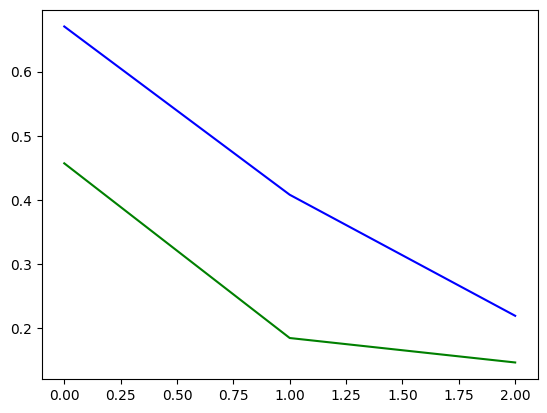

In [11]:
import matplotlib.pyplot as plt

plt.plot(trainLossArr, color="b")
plt.plot(valLossArr, color="g")
plt.show()



In [12]:
torch.save(model.state_dict(), "myFirstModel1.pth")



In [13]:
# Inference: produce predictions for each test id in order and write correct submission columns.
model.eval()
all_ids = []
all_preds = []

with torch.no_grad():
    for ids, (x, lengths) in testdl:
        x = x.to(device, non_blocking=True)
        lengths = lengths.to(device, non_blocking=True)
        logits = model(x, lengths)
        probs = torch.sigmoid(logits).detach().cpu().numpy()
        all_ids.extend(ids)
        all_preds.append(probs)

pred_mat = np.vstack(all_preds)



In [14]:
# Bugfix: ensure ordering/alignment by id and correct column set/order.
sub = pd.DataFrame({"id": all_ids})
for i, col in enumerate(TARGET_COLS):
    sub[col] = pred_mat[:, i].astype(np.float32)

# Align to sample_submission order if needed (safety against any DataLoader ordering issues)
sub = sample_sub[["id"]].merge(sub, on="id", how="left")
missing = sub[TARGET_COLS].isna().any(axis=1).sum()
if missing:
    # Should not happen; fill neutrally to keep a valid submission.
    sub[TARGET_COLS] = sub[TARGET_COLS].fillna(0.5)

sub.to_csv("submission.csv", index=False)
print(sub.head())
print("Wrote submission.csv with shape:", sub.shape)

                 id     toxic  severe_toxic  obscene    threat   insult  \
0  00001cee341fdb12  0.103215      0.026078  0.05786  0.021371  0.05263   
1  0000247867823ef7  0.103215      0.026078  0.05786  0.021371  0.05263   
2  00013b17ad220c46  0.103215      0.026078  0.05786  0.021371  0.05263   
3  00017563c3f7919a  0.103215      0.026078  0.05786  0.021371  0.05263   
4  00017695ad8997eb  0.103215      0.026078  0.05786  0.021371  0.05263   

   identity_hate  
0       0.024698  
1       0.024698  
2       0.024698  
3       0.024698  
4       0.024698  
Wrote submission.csv with shape: (153164, 7)
